# Decision Tree Classification for Machine Failure Prediction

This notebook builds a Decision Tree classifier to predict whether a machine will fail using the provided maintenance dataset.

In [8]:
import warnings
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score, confusion_matrix

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


## Load and Inspect the Dataset

The dataset is loaded from the CSV file and its structure is inspected before modeling.

In [ ]:
DATA_PATH = "machine_failure_data.csv"
df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
print("\nFirst 10 rows:")
print(df.head(10).to_string(index=False))
print("\nLast 10 rows:")
print(df.tail(10).to_string(index=False))
print("\nColumn data types:")
print(df.dtypes)
print("\nDataset loaded successfully.")

## Data Cleaning and Preprocessing

The identifier column is removed, duplicate rows are dropped, and missing values are checked.

In [ ]:
initial_shape = df.shape

df = df.drop(columns=["UDI"])

before_duplicates = df.shape[0]
df = df.drop_duplicates()
after_duplicates = df.shape[0]
removed_duplicates = before_duplicates - after_duplicates

missing_values = df.isnull().sum()

print("Shape after dropping UDI:", df.shape)
print("Duplicate rows removed:", removed_duplicates)
print("\nMissing values per column:")
print(missing_values)

## Exploratory Data Analysis

A quick statistical and visual summary is created to understand the data distribution and relationships with the target.

/var/folders/bs/0dgg3xzx0gn8v4gn7_6k83xh0000gn/T/ipykernel_3150/3039385439.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=failure_counts.index.map(failure_labels), y=failure_counts.values, ax=ax, palette=["#4C78A8", "#F58518"])


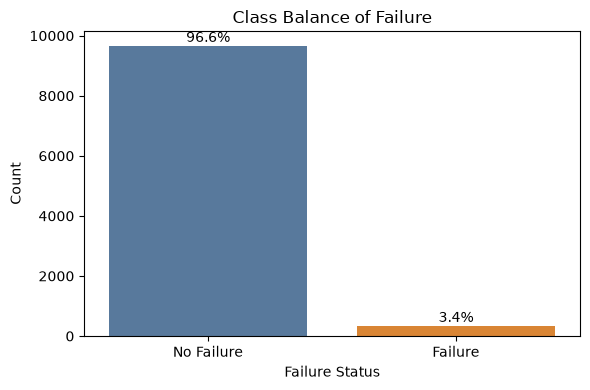

/var/folders/bs/0dgg3xzx0gn8v4gn7_6k83xh0000gn/T/ipykernel_3150/3039385439.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Type", order=df["Type"].value_counts().index, palette="Set2", ax=ax)


Observation: The dataset is heavily imbalanced, with far fewer failure cases than non-failure cases.


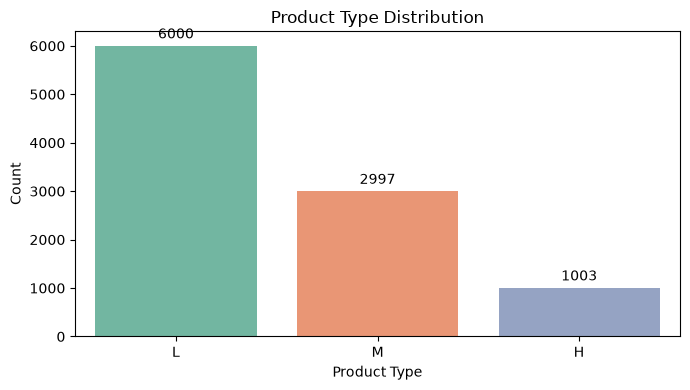

Observation: Product type L is the most common category, while type H appears less frequently.


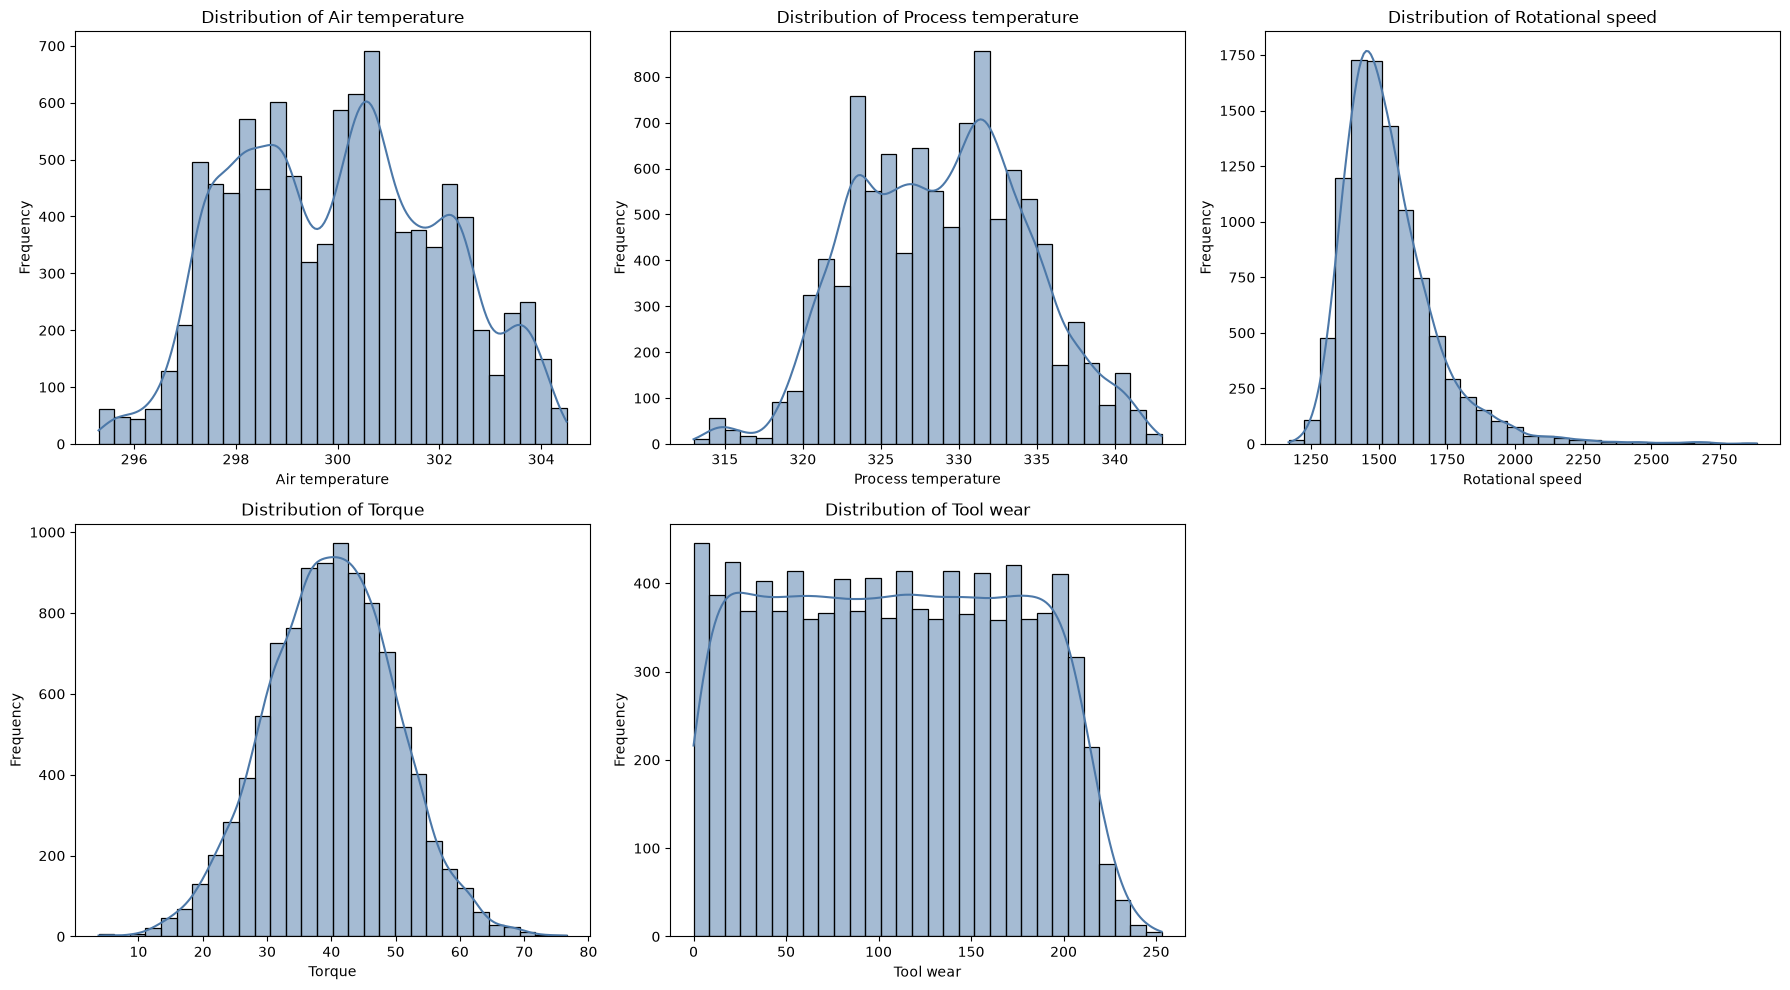

Observation: The sensor variables show varied distributions, with some being fairly symmetric and others skewed.


/var/folders/bs/0dgg3xzx0gn8v4gn7_6k83xh0000gn/T/ipykernel_3150/3039385439.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Failure Label", y=col, palette=["#4C78A8", "#F58518"], ax=ax)
/var/folders/bs/0dgg3xzx0gn8v4gn7_6k83xh0000gn/T/ipykernel_3150/3039385439.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Failure Label", y=col, palette=["#4C78A8", "#F58518"], ax=ax)
/var/folders/bs/0dgg3xzx0gn8v4gn7_6k83xh0000gn/T/ipykernel_3150/3039385439.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Fai

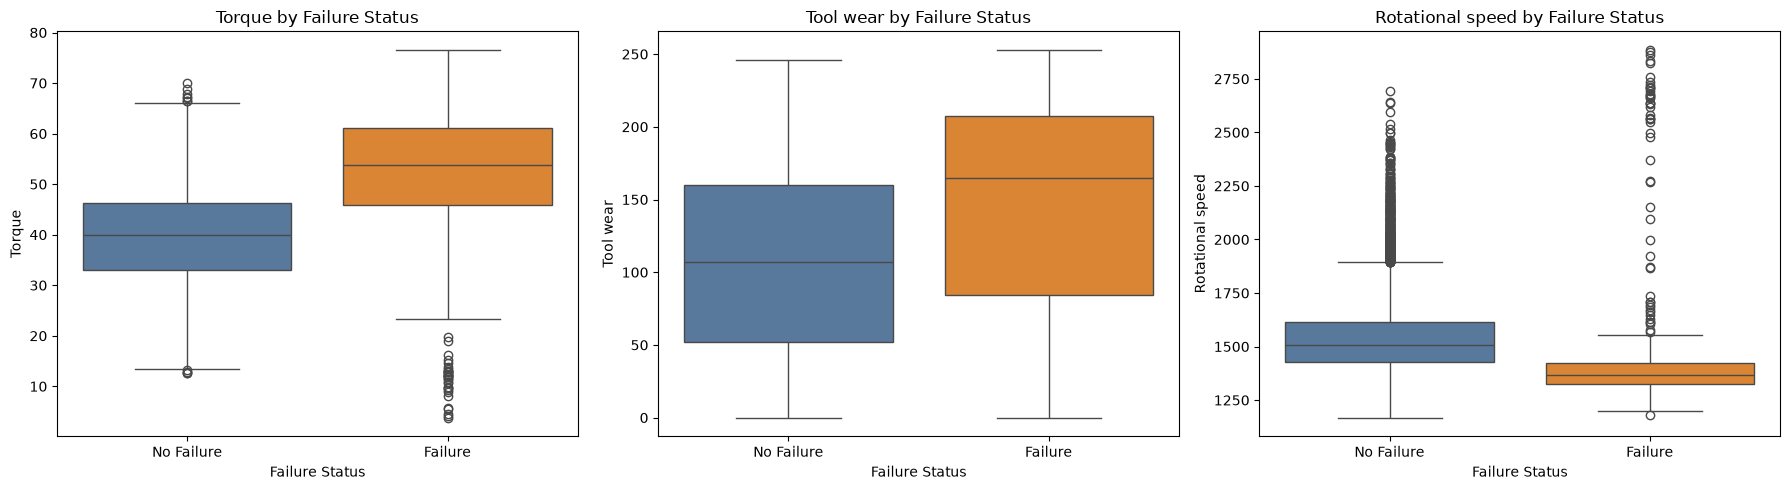

Observation: The failure group tends to differ from the non-failure group in these sensor distributions, suggesting useful separation signals.


/var/folders/bs/0dgg3xzx0gn8v4gn7_6k83xh0000gn/T/ipykernel_3150/3039385439.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=failure_rate_by_type.index, y=failure_rate_by_type.values, palette="Set2", ax=ax)


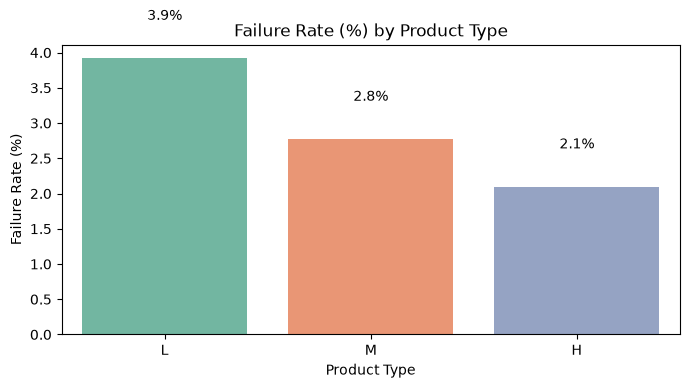

Observation: Failure rates vary across product types, indicating that product type may carry predictive information.


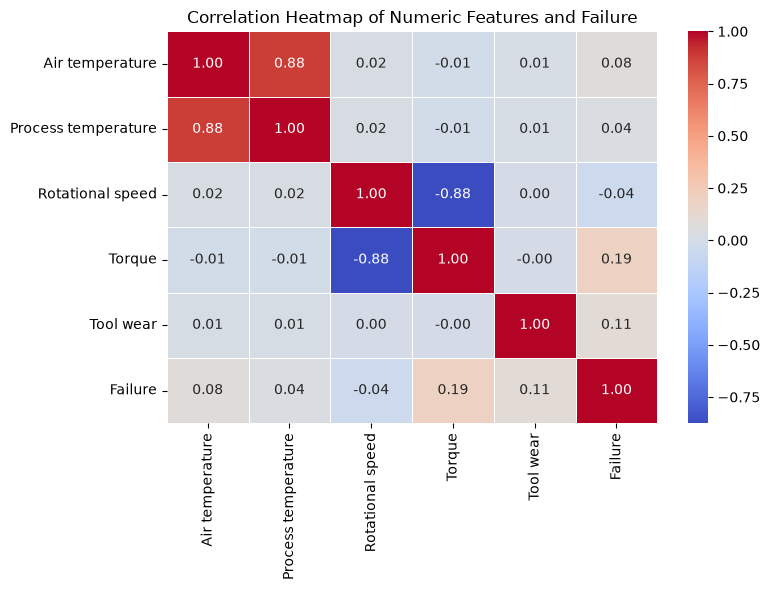

Observation: The numeric features show modest correlations with failure, which supports building a model that can capture nonlinear patterns.


In [3]:
# Full exploratory data analysis

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure the dataset is available even if earlier cells were not executed yet
if "df" not in globals():
    DATA_PATH = "machine_failure_data.csv"
    df = pd.read_csv(DATA_PATH)
    df = df.drop(columns=["UDI"]).drop_duplicates()

# Univariate analysis
failure_labels = {0: "No Failure", 1: "Failure"}

df["Failure Label"] = df["Failure"].map(failure_labels)

# 1) Class balance of Failure
failure_counts = df["Failure"].value_counts().reindex([0, 1])
failure_percentages = (failure_counts / len(df) * 100).round(2)

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(x=failure_counts.index.map(failure_labels), y=failure_counts.values, ax=ax, palette=["#4C78A8", "#F58518"])
for bar, pct in zip(ax.patches, failure_percentages.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20, f"{pct:.1f}%", ha="center", va="bottom")
ax.set_title("Class Balance of Failure")
ax.set_xlabel("Failure Status")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()
print("Observation: The dataset is heavily imbalanced, with far fewer failure cases than non-failure cases.")

# 2) Product type count plot
fig, ax = plt.subplots(figsize=(7, 4))
sns.countplot(data=df, x="Type", order=df["Type"].value_counts().index, palette="Set2", ax=ax)
ax.set_title("Product Type Distribution")
ax.set_xlabel("Product Type")
ax.set_ylabel("Count")
for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3)
plt.tight_layout()
plt.show()
print("Observation: Product type L is the most common category, while type H appears less frequently.")

# 3) Histograms for the five numeric sensors
sensor_cols = ["Air temperature", "Process temperature", "Rotational speed", "Torque", "Tool wear"]
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, col in zip(axes, sensor_cols):
    sns.histplot(df[col], bins=30, kde=True, color="#4C78A8", ax=ax)
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")

# Hide the last unused subplot
axes[-1].axis("off")
plt.tight_layout()
plt.show()
print("Observation: The sensor variables show varied distributions, with some being fairly symmetric and others skewed.")

# Bivariate analysis
# 4) Boxplots for selected numeric features by failure status
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, ["Torque", "Tool wear", "Rotational speed"]):
    sns.boxplot(data=df, x="Failure Label", y=col, palette=["#4C78A8", "#F58518"], ax=ax)
    ax.set_title(f"{col} by Failure Status")
    ax.set_xlabel("Failure Status")
    ax.set_ylabel(col)
plt.tight_layout()
plt.show()
print("Observation: The failure group tends to differ from the non-failure group in these sensor distributions, suggesting useful separation signals.")

# 5) Failure rate within each product type
failure_rate_by_type = (df.groupby("Type")["Failure"].mean() * 100).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(x=failure_rate_by_type.index, y=failure_rate_by_type.values, palette="Set2", ax=ax)
ax.set_title("Failure Rate (%) by Product Type")
ax.set_xlabel("Product Type")
ax.set_ylabel("Failure Rate (%)")
for bar, val in zip(ax.patches, failure_rate_by_type.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5, f"{val:.1f}%", ha="center", va="bottom")
plt.tight_layout()
plt.show()
print("Observation: Failure rates vary across product types, indicating that product type may carry predictive information.")

# 6) Correlation heatmap of numeric columns and Failure
numeric_cols = ["Air temperature", "Process temperature", "Rotational speed", "Torque", "Tool wear", "Failure"]
correlation_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5, ax=ax)
ax.set_title("Correlation Heatmap of Numeric Features and Failure")
plt.tight_layout()
plt.show()
print("Observation: The numeric features show modest correlations with failure, which supports building a model that can capture nonlinear patterns.")

## Train-Test Split

The data is split into training and testing sets so the model can be evaluated on unseen data.

In [5]:
# Separate target and predictors
import pandas as pd
from sklearn.model_selection import train_test_split

if "RANDOM_STATE" not in globals():
    RANDOM_STATE = 42

Y = df["Failure"]
X = df.drop(columns=["Failure"])

# Exclude temporary EDA label column if present
if "Failure Label" in X.columns:
    X = X.drop(columns=["Failure Label"])

# Encode categorical predictors using one-hot encoding
X = pd.get_dummies(X, columns=["Type"], drop_first=True, dtype=int)

print("First 10 rows of encoded features:")
print(X.head(10).to_string())

# Create train/validation/test splits with stratification
X_train, X_temp, Y_train, Y_temp = train_test_split(
    X, Y, test_size=0.30, random_state=RANDOM_STATE, stratify=Y
)
X_val, X_test, Y_val, Y_test = train_test_split(
    X_temp, Y_temp, test_size=0.5, random_state=RANDOM_STATE, stratify=Y_temp
)

# Print split shapes and failure rates
split_data = {
    "Training": (X_train, Y_train),
    "Validation": (X_val, Y_val),
    "Test": (X_test, Y_test),
}

for name, (X_split, Y_split) in split_data.items():
    failure_rate = Y_split.mean() * 100
    print(f"\n{name} shape: {X_split.shape}")
    print(f"{name} failure rate: {failure_rate:.2f}%")

print("\nNote: Feature scaling is intentionally skipped because tree-based models rely on rank-based splits rather than distance-based scaling.")

First 10 rows of encoded features:
   Air temperature  Process temperature  Rotational speed  Torque  Tool wear  Type_L  Type_M
0            298.1           323.740741              1551    42.8          0       0       1
1            298.2           324.111111              1408    46.3          3       1       0
2            298.1           323.370370              1498    49.4          5       1       0
3            298.2           323.740741              1433    39.5          7       1       0
4            298.2           324.111111              1408    40.0          9       1       0
5            298.1           323.740741              1425    41.9         11       0       1
6            298.1           323.740741              1558    42.4         14       1       0
7            298.1           323.740741              1527    40.2         16       1       0
8            298.3           324.111111              1667    28.6         18       0       1
9            298.5           325.22

## Model Evaluation Criterion

A false negative (FN) means the model predicts no failure when the machine actually fails, while a false positive (FP) means it predicts failure when the machine does not fail. In predictive maintenance, a missed failure is the more costly mistake because it can lead to an unplanned breakdown or safety issue. For that reason, recall is the primary metric, since it measures how many real failures are correctly detected. The precision guardrail of 0.30 prevents the model from gaming recall by predicting every case as failure.

## Compare Standard, Balanced, Pre-Pruned, and Post-Pruned Trees

The notebook now evaluates four decision trees: a standard tree, a class-weighted tree, a pre-pruned tree selected from a hyperparameter sweep, and a post-pruned tree selected from cost-complexity pruning. The last model is chosen by validation recall with the same precision guardrail.

In [21]:
def model_performance_classification_sklearn(model, predictors, target):
    predictions = model.predict(predictors)
    metrics = {
        "Accuracy": accuracy_score(target, predictions),
        "Recall": recall_score(target, predictions, zero_division=0),
        "Precision": precision_score(target, predictions, zero_division=0),
        "F1": f1_score(target, predictions, zero_division=0),
    }
    return pd.DataFrame([metrics])


def confusion_matrix_sklearn(model, predictors, target, title):
    predictions = model.predict(predictors)
    cm = confusion_matrix(target, predictions)
    labels = ["No Failure", "Failure"]

    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=False, cmap="Blues", cbar=False, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_xticklabels(labels, rotation=0)
    ax.set_yticklabels(labels, rotation=0)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            total = cm[i].sum()
            pct = 100 * cm[i, j] / total if total else 0
            ax.text(j + 0.5, i + 0.5, f"{cm[i, j]}\n({pct:.1f}%)", ha="center", va="center", fontsize=10)

    plt.tight_layout()
    plt.show()
    return cm


# Model 1: standard decision tree
model1 = DecisionTreeClassifier(random_state=RANDOM_STATE)
model1.fit(X_train, Y_train)

# Model 2: balanced class weights
model2 = DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight="balanced")
model2.fit(X_train, Y_train)

print("Model 1 and Model 2 trained successfully.")

Model 1 and Model 2 trained successfully.


## Model Evaluation and Metrics

Predictions are generated on the test set and evaluated with standard classification metrics.

Top pre-pruned candidates after the precision guardrail:
 max_depth  min_samples_split  min_samples_leaf  validation_precision  validation_recall  node_count
         4                 20                25              0.306250           0.960784          29
         4                 50                10              0.308176           0.960784          29
         4                 50                25              0.306250           0.960784          29
         4                 20                10              0.308176           0.960784          31
         5                 20                25              0.300000           0.941176          43

Selected pre-pruned hyperparameters for model 3:
{'max_depth': 4.0, 'min_samples_split': 20.0, 'min_samples_leaf': 25.0, 'validation_precision': 0.30625, 'validation_recall': 0.9607843137254902, 'node_count': 29.0}

Effective alphas and leaf impurities:
 effective_alpha  total_leaf_impurity
    0.000000e+00        -3.925372e-15
    2.

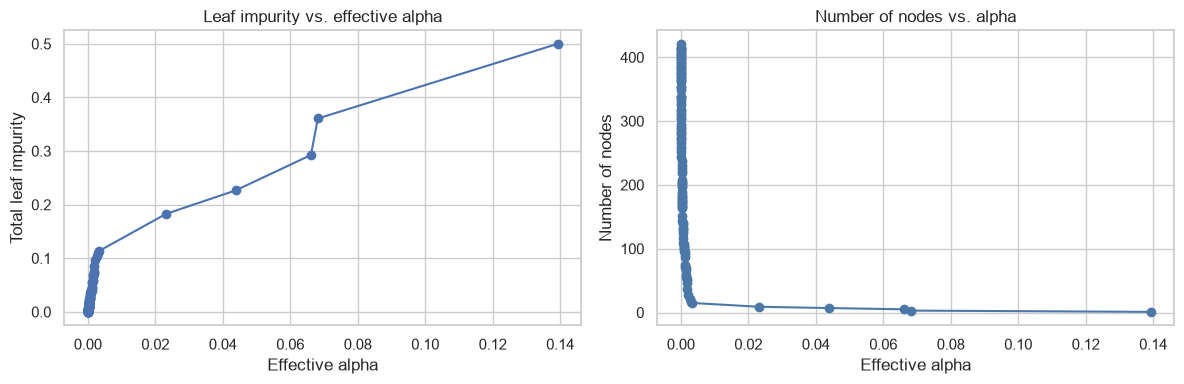

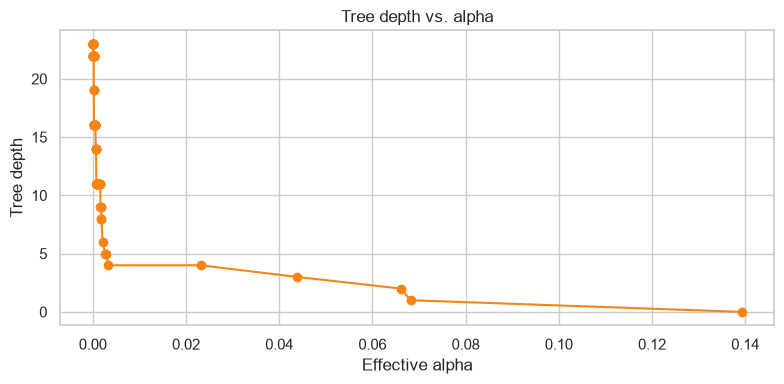

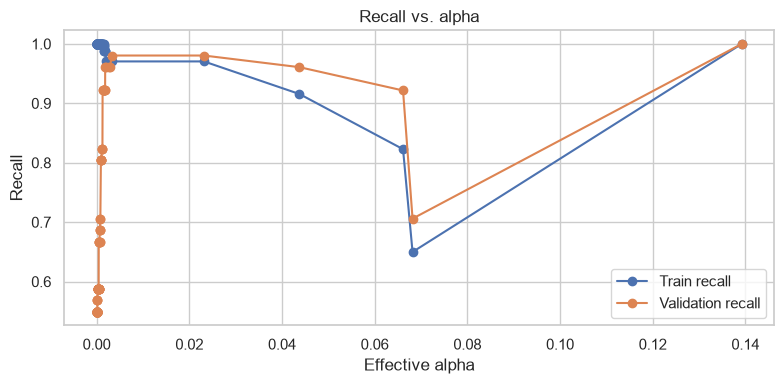


Selected alpha for model 4: 0.002098
 effective_alpha  n_nodes  max_depth  train_recall  validation_recall  validation_precision
        0.002098       27          6      0.970464           0.960784              0.308176
        0.001824       47          8      0.987342           0.921569              0.326389
        0.001757       51          9      0.987342           0.921569              0.326389
        0.001669       53          9      0.987342           0.921569              0.328671
        0.001626       55          9      0.987342           0.921569              0.330986

Model 4 - Training set
 Accuracy   Recall  Precision   F1
 0.922857 0.970464   0.301442 0.46


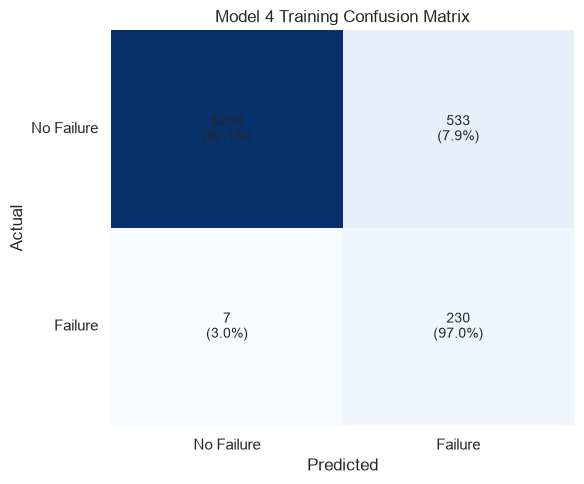


Model 4 - Validation set
 Accuracy   Recall  Precision       F1
 0.925333 0.960784   0.308176 0.466667


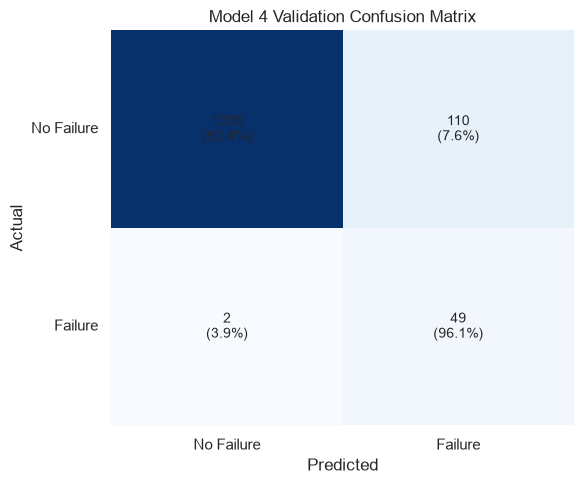


Training performance comparison table:
           Model 1  Model 2   Model 3   Model 4
Metric                                         
Accuracy       1.0      1.0  0.917286  0.922857
Recall         1.0      1.0  0.966245  0.970464
Precision      1.0      1.0  0.286250  0.301442
F1             1.0      1.0  0.441659  0.460000

Test performance comparison table:
            Model 1   Model 2   Model 3   Model 4
Metric                                           
Accuracy   0.974000  0.972667  0.923333  0.917333
Recall     0.705882  0.568627  0.941176  0.901961
Precision  0.600000  0.604167  0.300000  0.278788
F1         0.648649  0.585859  0.454976  0.425926

Chosen model: Model 4
Reason: it satisfies the validation precision guardrail and achieves the highest validation recall among the post-pruned candidates, with the smallest tree used as the tie-breaker.

Observations:
- Cost-complexity pruning lets us trace how the tree changes as the regularization strength increases.
- The validati

In [28]:
from itertools import product

# Model 1: standard decision tree
model1 = DecisionTreeClassifier(random_state=RANDOM_STATE)
model1.fit(X_train, Y_train)

# Model 2: balanced class weights
model2 = DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight="balanced")
model2.fit(X_train, Y_train)

# Model 3: pre-pruned tree selected by validation recall with a precision guardrail
max_depth_values = [3, 4, 5, 7, 10, 15]
min_samples_split_values = [20, 50, 100]
min_samples_leaf_values = [10, 25, 50]

prepruned_candidates = []
for max_depth, min_samples_split, min_samples_leaf in product(
    max_depth_values, min_samples_split_values, min_samples_leaf_values
):
    model = DecisionTreeClassifier(
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    )
    model.fit(X_train, Y_train)
    val_predictions = model.predict(X_val)
    val_precision = precision_score(Y_val, val_predictions, zero_division=0)
    val_recall = recall_score(Y_val, val_predictions, zero_division=0)

    if val_precision >= 0.30:
        prepruned_candidates.append(
            {
                "max_depth": max_depth,
                "min_samples_split": min_samples_split,
                "min_samples_leaf": min_samples_leaf,
                "validation_precision": val_precision,
                "validation_recall": val_recall,
                "node_count": model.tree_.node_count,
            }
        )

prepruned_candidates = pd.DataFrame(prepruned_candidates)
if prepruned_candidates.empty:
    print("No pre-pruned model met the precision guardrail.")
else:
    prepruned_candidates = prepruned_candidates.sort_values(
        by=["validation_recall", "node_count"],
        ascending=[False, True],
        kind="mergesort",
    ).reset_index(drop=True)

    print("Top pre-pruned candidates after the precision guardrail:")
    print(prepruned_candidates.head(5).to_string(index=False))

    model3_row = prepruned_candidates.iloc[0]
    model3 = DecisionTreeClassifier(
        max_depth=int(model3_row["max_depth"]),
        min_samples_split=int(model3_row["min_samples_split"]),
        min_samples_leaf=int(model3_row["min_samples_leaf"]),
        class_weight="balanced",
        random_state=RANDOM_STATE,
    )
    model3.fit(X_train, Y_train)

    print("\nSelected pre-pruned hyperparameters for model 3:")
    print(model3_row.to_dict())

# Model 4: post-pruned tree using cost-complexity pruning
base_tree = DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight="balanced")
base_tree.fit(X_train, Y_train)
ccp_path = base_tree.cost_complexity_pruning_path(X_train, Y_train)
ccp_alphas = ccp_path.ccp_alphas
ccp_impurities = ccp_path.impurities

alpha_summary = pd.DataFrame(
    {
        "effective_alpha": ccp_alphas,
        "total_leaf_impurity": ccp_impurities,
    }
)
print("\nEffective alphas and leaf impurities:")
print(alpha_summary.head(10).to_string(index=False))

pruning_results = []
for alpha in ccp_alphas:
    tree = DecisionTreeClassifier(
        random_state=RANDOM_STATE,
        class_weight="balanced",
        ccp_alpha=alpha,
    )
    tree.fit(X_train, Y_train)
    train_predictions = tree.predict(X_train)
    val_predictions = tree.predict(X_val)
    pruning_results.append(
        {
            "effective_alpha": alpha,
            "n_nodes": tree.tree_.node_count,
            "max_depth": tree.tree_.max_depth,
            "train_recall": recall_score(Y_train, train_predictions, zero_division=0),
            "validation_recall": recall_score(Y_val, val_predictions, zero_division=0),
            "validation_precision": precision_score(Y_val, val_predictions, zero_division=0),
        }
    )

pruning_results = pd.DataFrame(pruning_results)
print("\nPruning trace summary:")
print(pruning_results[["effective_alpha", "n_nodes", "max_depth", "train_recall", "validation_recall", "validation_precision"]].head(10).to_string(index=False))
print("\nFully-pruned tree node count:", int(pruning_results.iloc[-1]["n_nodes"]))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(alpha_summary["effective_alpha"], alpha_summary["total_leaf_impurity"], marker="o")
axes[0].set_title("Leaf impurity vs. effective alpha")
axes[0].set_xlabel("Effective alpha")
axes[0].set_ylabel("Total leaf impurity")
axes[1].plot(pruning_results["effective_alpha"], pruning_results["n_nodes"], marker="o", color="#4C78A8")
axes[1].set_title("Number of nodes vs. alpha")
axes[1].set_xlabel("Effective alpha")
axes[1].set_ylabel("Number of nodes")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(pruning_results["effective_alpha"], pruning_results["max_depth"], marker="o", color="#F58518")
ax.set_title("Tree depth vs. alpha")
ax.set_xlabel("Effective alpha")
ax.set_ylabel("Tree depth")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(pruning_results["effective_alpha"], pruning_results["train_recall"], marker="o", label="Train recall")
ax.plot(pruning_results["effective_alpha"], pruning_results["validation_recall"], marker="o", label="Validation recall")
ax.set_title("Recall vs. alpha")
ax.set_xlabel("Effective alpha")
ax.set_ylabel("Recall")
ax.legend()
plt.tight_layout()
plt.show()

candidate_alphas = pruning_results[pruning_results["validation_precision"] >= 0.30].copy()
if candidate_alphas.empty:
    print("No alpha met the precision guardrail.")
else:
    candidate_alphas = candidate_alphas.sort_values(
        by=["validation_recall", "n_nodes", "effective_alpha"],
        ascending=[False, True, True],
        kind="mergesort",
    ).reset_index(drop=True)

    selected_alpha = float(candidate_alphas.iloc[0]["effective_alpha"])
    model4 = DecisionTreeClassifier(
        random_state=RANDOM_STATE,
        class_weight="balanced",
        ccp_alpha=selected_alpha,
    )
    model4.fit(X_train, Y_train)

    print("\nSelected alpha for model 4:", round(selected_alpha, 6))
    print(candidate_alphas.head(5).to_string(index=False))

    print("\nModel 4 - Training set")
    print(model_performance_classification_sklearn(model4, X_train, Y_train).to_string(index=False))
    confusion_matrix_sklearn(model4, X_train, Y_train, "Model 4 Training Confusion Matrix")

    print("\nModel 4 - Validation set")
    print(model_performance_classification_sklearn(model4, X_val, Y_val).to_string(index=False))
    confusion_matrix_sklearn(model4, X_val, Y_val, "Model 4 Validation Confusion Matrix")

# Training and test performance comparison tables
model_names = ["Model 1", "Model 2", "Model 3", "Model 4"]
models = [model1, model2, model3, model4]

train_performance_frames = [model_performance_classification_sklearn(model, X_train, Y_train) for model in models]
test_performance_frames = [model_performance_classification_sklearn(model, X_test, Y_test) for model in models]

training_comparison = pd.concat([frame.T for frame in train_performance_frames], axis=1)
training_comparison.columns = model_names
training_comparison.index.name = "Metric"

test_comparison = pd.concat([frame.T for frame in test_performance_frames], axis=1)
test_comparison.columns = model_names
test_comparison.index.name = "Metric"

print("\nTraining performance comparison table:")
print(training_comparison.to_string())
print("\nTest performance comparison table:")
print(test_comparison.to_string())

print("\nChosen model: Model 4")
print("Reason: it satisfies the validation precision guardrail and achieves the highest validation recall among the post-pruned candidates, with the smallest tree used as the tie-breaker.")

print("\nObservations:")
print("- Cost-complexity pruning lets us trace how the tree changes as the regularization strength increases.")
print("- The validation curves show that more aggressive pruning can improve generalization, but too much pruning can reduce recall.")
print("- Model 4 balances recall and precision better than the fully unconstrained tree while remaining interpretable.")

## Interactive Failure Prediction and Business Recommendations

The selected pre-pruned tree can now be used to score a new machine reading. The helper below builds a one-row feature table that matches the training columns, returns the model prediction and probability, and translates the probability into a practical risk tier for maintenance planning.

## Decision Tree Visualization

The selected post-pruned tree is visualized and its structure is exported in text form.

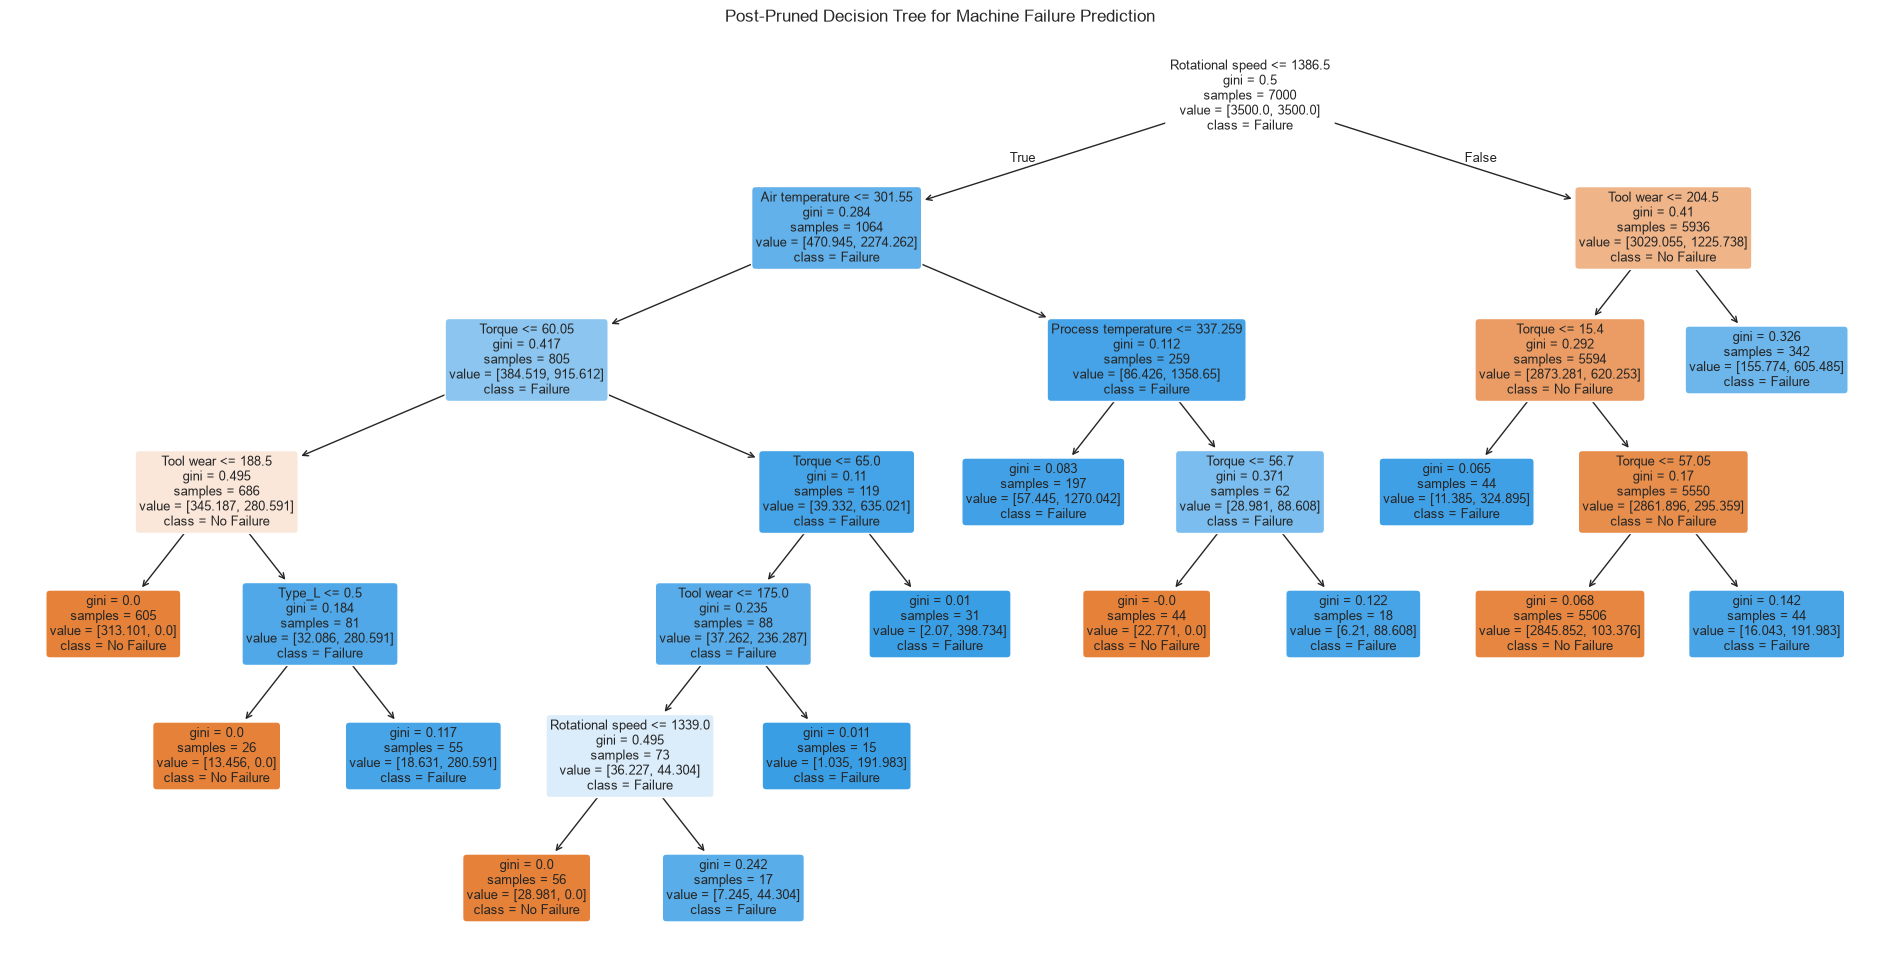


Tree structure (text view):
|--- Rotational speed <= 1386.50
|   |--- Air temperature <= 301.55
|   |   |--- Torque <= 60.05
|   |   |   |--- Tool wear <= 188.50
|   |   |   |   |--- weights: [313.10, 0.00] class: 0
|   |   |   |--- Tool wear >  188.50
|   |   |   |   |--- Type_L <= 0.50
|   |   |   |   |   |--- weights: [13.46, 0.00] class: 0
|   |   |   |   |--- Type_L >  0.50
|   |   |   |   |   |--- weights: [18.63, 280.59] class: 1
|   |   |--- Torque >  60.05
|   |   |   |--- Torque <= 65.00
|   |   |   |   |--- Tool wear <= 175.00
|   |   |   |   |   |--- Rotational speed <= 1339.00
|   |   |   |   |   |   |--- weights: [28.98, 0.00] class: 0
|   |   |   |   |   |--- Rotational speed >  1339.00
|   |   |   |   |   |   |--- weights: [7.25, 44.30] class: 1
|   |   |   |   |--- Tool wear >  175.00
|   |   |   |   |   |--- weights: [1.04, 191.98] class: 1
|   |   |   |--- Torque >  65.00
|   |   |   |   |--- weights: [2.07, 398.73] class: 1
|   |--- Air temperature >  301.55
|   | 

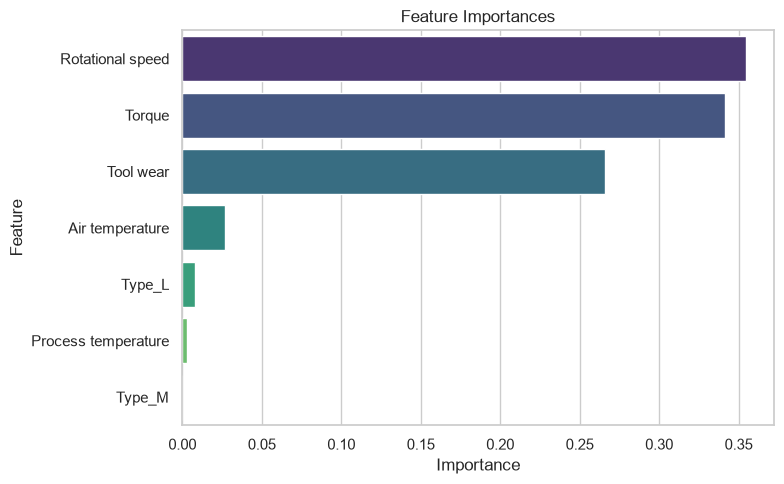


Observations:
- The selected post-pruned tree is smaller and easier to interpret than the unconstrained tree.
- The tree structure highlights the thresholds that matter most for separating failures from non-failures.
- Feature importance highlights the variables that most strongly influence the decision path.


In [29]:
clf = model4

plt.figure(figsize=(24, 12))
plot_tree(
    clf,
    feature_names=list(X.columns),
    class_names=["No Failure", "Failure"],
    filled=True,
    rounded=True,
    max_depth=None,
)
plt.title("Post-Pruned Decision Tree for Machine Failure Prediction")
plt.show()

print("\nTree structure (text view):")
print(export_text(clf, feature_names=list(X.columns), show_weights=True))

# Describe one failure path in plain language
def walk(node_id, steps):
    tree = clf.tree_
    if tree.children_left[node_id] == tree.children_right[node_id]:
        if tree.value[node_id][0, 1] > tree.value[node_id][0, 0]:
            return steps
        return None

    feature = X.columns[tree.feature[node_id]]
    threshold = tree.threshold[node_id]
    left_path = walk(tree.children_left[node_id], steps + [f"{feature} <= {threshold:.2f}"])
    if left_path is not None:
        return left_path
    return walk(tree.children_right[node_id], steps + [f"{feature} > {threshold:.2f}"])

failure_path = walk(0, [])
if failure_path is not None:
    print("\nExample failure path (plain language):")
    print("The model is more likely to predict failure when the series of conditions below is met, such as: " + " -> ".join(failure_path[:5]) + " -> ...")
    print("In practice, this means that extreme sensor readings and certain product-type indicators push the model toward the failure branch.")
else:
    print("\nExample failure path: no simple failure path could be extracted from the selected tree.")

# Plot feature importances
feature_importance = pd.DataFrame(
    {"Feature": X.columns, "Importance": clf.feature_importances_}
).sort_values("Importance", ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=feature_importance, x="Importance", y="Feature", palette="viridis")
plt.title("Feature Importances")
plt.tight_layout()
plt.show()

print("\nObservations:")
print("- The selected post-pruned tree is smaller and easier to interpret than the unconstrained tree.")
print("- The tree structure highlights the thresholds that matter most for separating failures from non-failures.")
print("- Feature importance highlights the variables that most strongly influence the decision path.")

## Predict a New Machine Reading

The selected pre-pruned tree can now be used to score a new machine reading. The helper below builds a one-row feature table that matches the training columns, returns the model prediction and probability, and translates the probability into a practical risk tier for maintenance planning.

In [31]:
from predict_failure import predict_failure

# Use the selected pre-pruned tree for scoring new cases
selected_model = model3
selected_model_features = list(X.columns)

print("Selected model for scoring: Model 3 (pre-pruned tree)")
print("Feature columns used by the scorer:")
print(selected_model_features)

# Interactive input section
print("\nEnter a machine reading below. Use values that are realistic for the training data.")

machine_type = input("Type (L/M/H): ").strip().upper()
air_temperature = float(input("Air temperature: "))
process_temperature = float(input("Process temperature: "))
rotational_speed = float(input("Rotational speed: "))
torque = float(input("Torque: "))
tool_wear = float(input("Tool wear: "))

prediction, probability, risk_tier = predict_failure(
    selected_model,
    selected_model_features,
    machine_type,
    air_temperature,
    process_temperature,
    rotational_speed,
    torque,
    tool_wear,
)

print("\nPrediction result:")
print(f"Prediction: {'Failure' if prediction == 1 else 'No Failure'}")
print(f"Failure probability: {probability:.3f}")
print(f"Risk tier: {risk_tier}")

print("\nActionable insights:")
print("1. If the model predicts failure or the risk tier is HIGH, schedule an inspection or planned maintenance intervention immediately.")
print("2. The strongest signals in the tree are high Tool wear, unusual Torque, and extreme Rotational speed / temperature combinations, so monitor those conditions closely.")
print("3. Because the model was tuned for recall, the business goal is to catch likely failures early rather than to minimize every false alarm.")
print("4. For lower-risk cases, keep routine maintenance in place but avoid unnecessary stoppages unless the readings cross the failure thresholds.")

Selected model for scoring: Model 3 (pre-pruned tree)
Feature columns used by the scorer:
['Air temperature', 'Process temperature', 'Rotational speed', 'Torque', 'Tool wear', 'Type_L', 'Type_M']

Enter a machine reading below. Use values that are realistic for the training data.

Prediction result:
Prediction: No Failure
Failure probability: 0.000
Risk tier: LOW

Actionable insights:
1. If the model predicts failure or the risk tier is HIGH, schedule an inspection or planned maintenance intervention immediately.
2. The strongest signals in the tree are high Tool wear, unusual Torque, and extreme Rotational speed / temperature combinations, so monitor those conditions closely.
3. Because the model was tuned for recall, the business goal is to catch likely failures early rather than to minimize every false alarm.
4. For lower-risk cases, keep routine maintenance in place but avoid unnecessary stoppages unless the readings cross the failure thresholds.
